# Install the necessary library for the preject

In [1]:
pip install pandas numpy statsmodels seaborn scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

## Data loading and cleaning

In [3]:
df = pd.read_csv("Invistico_Airline.csv")

In [4]:
df.head()

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


In [5]:
df["Class"].value_counts()

Class
Business    62160
Eco         58309
Eco Plus     9411
Name: count, dtype: int64

In [6]:
df["Type of Travel"].value_counts()

Type of Travel
Business travel    89693
Personal Travel    40187
Name: count, dtype: int64

In [7]:
df["Customer Type"].value_counts()

Customer Type
Loyal Customer       106100
disloyal Customer     23780
Name: count, dtype: int64

In [8]:
df.isnull().sum()

satisfaction                           0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Seat comfort                           0
Departure/Arrival time convenient      0
Food and drink                         0
Gate location                          0
Inflight wifi service                  0
Inflight entertainment                 0
Online support                         0
Ease of Online booking                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Online boarding                        0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
dtype: int64

In [9]:
df["satisfaction"].value_counts()

satisfaction
satisfied       71087
dissatisfied    58793
Name: count, dtype: int64

In [10]:
df = df.dropna()

In [11]:
df["satisfaction"] = df["satisfaction"].replace({"satisfied":1, "dissatisfied":0})

In [12]:
df = pd.get_dummies(df, columns=["Customer Type", "Type of Travel", "Class"], drop_first=True)

In [13]:
df = df.astype(int)

In [14]:
df.head()

,satisfaction,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,...,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Class_Eco,Class_Eco Plus
0,1,65,265,0,0,0,2,2,4,2,...,3,5,3,2,0,0,0,1,1,0
1,1,47,2464,0,0,0,3,0,2,2,...,4,2,3,2,310,305,0,1,0,0
2,1,15,2138,0,0,0,3,2,0,2,...,4,4,4,2,0,0,0,1,1,0
3,1,60,623,0,0,0,3,3,4,3,...,1,4,1,3,0,0,0,1,1,0
4,1,70,354,0,0,0,3,4,3,4,...,2,4,2,5,0,0,0,1,1,0


## Train-Test Split

In [15]:
X = df.drop("satisfaction", axis=1)
y = df["satisfaction"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
log_model = LogisticRegression(max_iter = 1000)
log_model.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

## Evaluate the Model (Confusion Matrix, Precision, and Recall)

In [19]:
prediction = log_model.predict(X_test_scaled)

In [20]:
cm = confusion_matrix(y_test, prediction)

In [21]:
cm

array([[ 9591,  2230],
       [ 2186, 11891]])

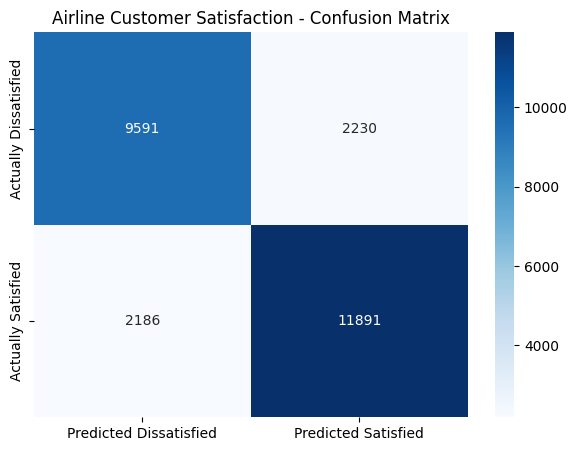

In [22]:
plt.figure(figsize=(7, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Dissatisfied', 'Predicted Satisfied'],
            yticklabels=['Actually Dissatisfied', 'Actually Satisfied'])
plt.title('Airline Customer Satisfaction - Confusion Matrix')
plt.show()

In [24]:
classification_report(y_test, prediction, target_names=['Dissatisfied (0)', 'Satisfied (1)'])

'                  precision    recall  f1-score   support\n\nDissatisfied (0)       0.81      0.81      0.81     11821\n   Satisfied (1)       0.84      0.84      0.84     14077\n\n        accuracy                           0.83     25898\n       macro avg       0.83      0.83      0.83     25898\n    weighted avg       0.83      0.83      0.83     25898\n'

## Interpret Model Coefficients (The "Why")

In [26]:
feature_name = X.columns
feature_name

Index(['Age', 'Flight Distance', 'Seat comfort',
       'Departure/Arrival time convenient', 'Food and drink', 'Gate location',
       'Inflight wifi service', 'Inflight entertainment', 'Online support',
       'Ease of Online booking', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding',
       'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'Customer Type_disloyal Customer', 'Type of Travel_Personal Travel',
       'Class_Eco', 'Class_Eco Plus'],
      dtype='str')

In [28]:
coefficients = log_model.coef_[0]
coefficients

array([-0.13492049, -0.18418361,  0.39968417, -0.33807345, -0.29424128,
        0.16867624, -0.13289935,  0.96147164,  0.14337917,  0.32609595,
        0.40228854,  0.30417534,  0.10358999,  0.36082112,  0.06840245,
        0.19904418,  0.12026543, -0.30573622, -0.72801318, -0.35072357,
       -0.35498821, -0.20302249])

In [29]:
coef_df = pd.DataFrame({'Feature': feature_name, 'Impact on Satisfaction': coefficients})
coef_df = coef_df.sort_values(by = 'Impact on Satisfaction', ascending=False)
coef_df

,Feature,Impact on Satisfaction
7,Inflight entertainment,0.961472
10,On-board service,0.402289
2,Seat comfort,0.399684
13,Checkin service,0.360821
9,Ease of Online booking,0.326096
11,Leg room service,0.304175
15,Online boarding,0.199044
5,Gate location,0.168676
8,Online support,0.143379
16,Departure Delay in Minutes,0.120265


## Business recommendations for how the airline can act on model insights

1. Invest heavily in "Inflight Entertainment" upgrades.
    The Data Insight: The model found that Inflight Entertainment has a coefficient of +0.96, making it the single most powerful driver of customer satisfaction in the entire dataset.

    The Actionable Recommendation: The airline should immediately allocate capital expenditure toward upgrading seatback screens, expanding the library of free movies and television shows, and ensuring the screens are highly responsive. When passengers are entertained, they are highly likely to forgive other minor inconveniences during the flight.

2. Overhaul the experience for "Disloyal" (First-Time/Infrequent) Customers.
    
    The Data Insight: The model flagged the Customer Type_disloyal Customer feature with a massive negative coefficient of -0.72. This means that if a passenger is flying with the airline for the first time or does not fly often, they are highly predisposed to leaving angry, dissatisfied feedback.

    The Actionable Recommendation: The airline needs to stop treating first-time flyers exactly the same as everyone else. They should implement a system where flight attendants are specifically notified on their digital manifests when a passenger is a "disloyal/new" customer. Flight attendants can then proactively check on them, offer a complimentary drink, or simply welcome them to the airline to convert that negative bias into long-term loyalty.